Dataset Shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

===== BEFORE TUNING =====
Accuracy: 0.7951219512195122
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80    

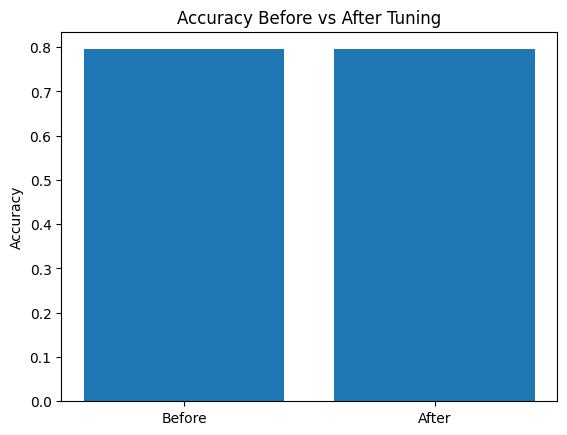

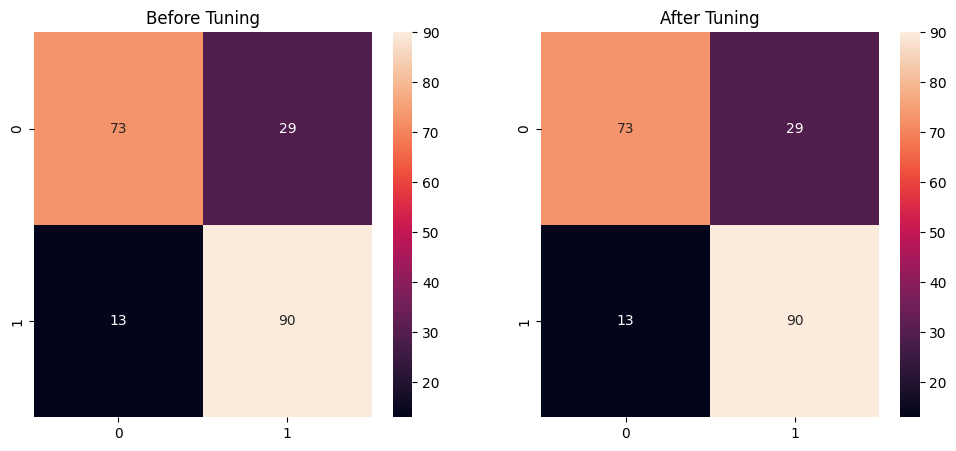

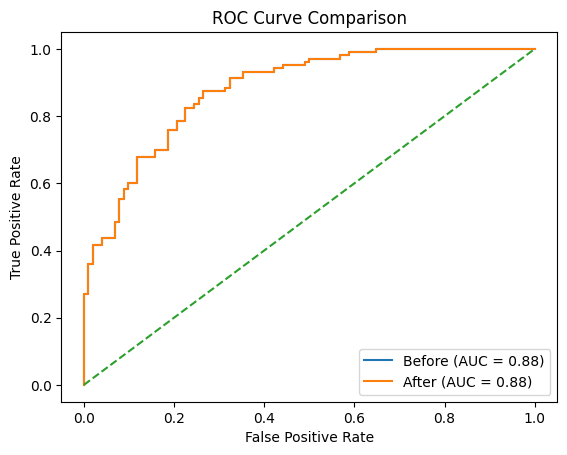

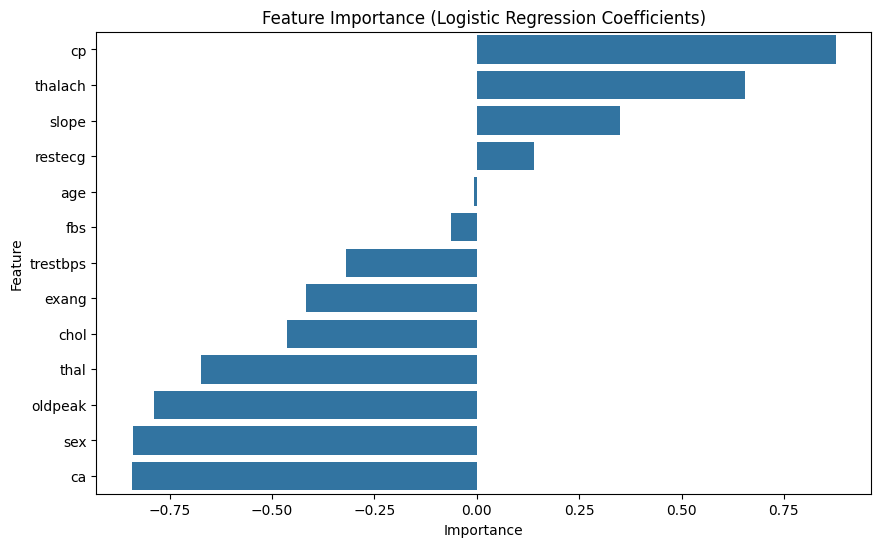


Top Features:
     Feature  Importance
2        cp    0.877341
7   thalach    0.654871
10    slope    0.349357
6   restecg    0.140684
0       age   -0.006754


In [5]:
# ==========================================
# STEP 1: Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# ==========================================
# STEP 2: Load Dataset
# ==========================================
df = pd.read_csv('/content/heart.csv')  # Upload dataset

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# STEP 3: Preprocessing
# ==========================================
X = df.drop("target", axis=1)
y = df["target"]

# Save feature names for later
feature_names = X.columns

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# ==========================================
# STEP 4: Logistic Regression (BEFORE TUNING)
# ==========================================
model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
y_prob_before = model_before.predict_proba(X_test)[:, 1]

acc_before = accuracy_score(y_test, y_pred_before)

print("\n===== BEFORE TUNING =====")
print("Accuracy:", acc_before)
print(classification_report(y_test, y_pred_before))

# ==========================================
# STEP 5: Hyperparameter Tuning
# ==========================================
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# ==========================================
# STEP 6: AFTER TUNING
# ==========================================
model_after = grid.best_estimator_

y_pred_after = model_after.predict(X_test)
y_prob_after = model_after.predict_proba(X_test)[:, 1]

acc_after = accuracy_score(y_test, y_pred_after)

print("\n===== AFTER TUNING =====")
print("Accuracy:", acc_after)
print(classification_report(y_test, y_pred_after))

# ==========================================
# STEP 7: ACCURACY COMPARISON GRAPH
# ==========================================
plt.figure()
models = ['Before', 'After']
accuracy = [acc_before, acc_after]

plt.bar(models, accuracy)
plt.title("Accuracy Before vs After Tuning")
plt.ylabel("Accuracy")
plt.show()

# ==========================================
# STEP 8: CONFUSION MATRIX (SIDE BY SIDE)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred_before), annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Before Tuning")

sns.heatmap(confusion_matrix(y_test, y_pred_after), annot=True, fmt='d', ax=axes[1])
axes[1].set_title("After Tuning")

plt.show()

# ==========================================
# STEP 9: SINGLE ROC CURVE (COMBINED)
# ==========================================
fpr1, tpr1, _ = roc_curve(y_test, y_prob_before)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_after)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)

plt.figure()
plt.plot(fpr1, tpr1, label=f"Before (AUC = {auc1:.2f})")
plt.plot(fpr2, tpr2, label=f"After (AUC = {auc2:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==========================================
# STEP 10: FEATURE IMPORTANCE (VERY IMPORTANT)
# ==========================================
coefficients = model_after.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

print("\nTop Features:\n", feature_importance.head())


===== LINEAR REGRESSION =====
R2 Score: 0.40960801060785557
MSE: 0.14759448520056795


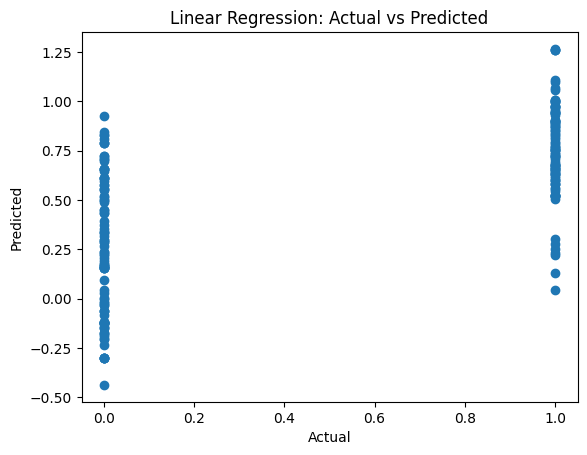


===== LOGISTIC BEFORE =====
Accuracy: 0.7951219512195122
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205


===== LOGISTIC AFTER =====
Accuracy: 0.7951219512195122
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



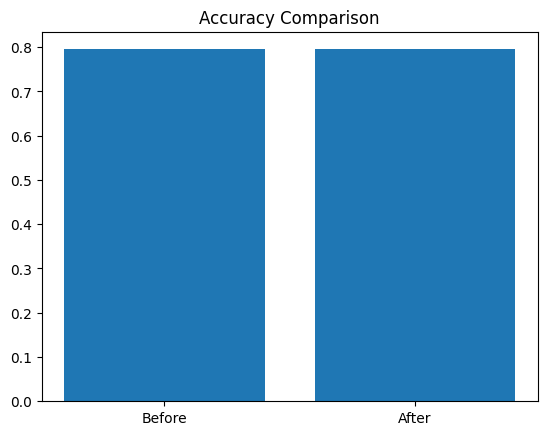

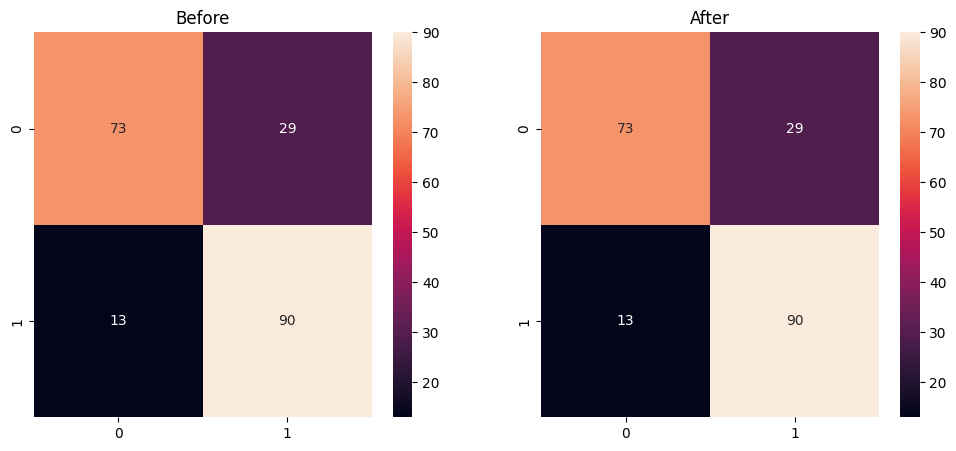

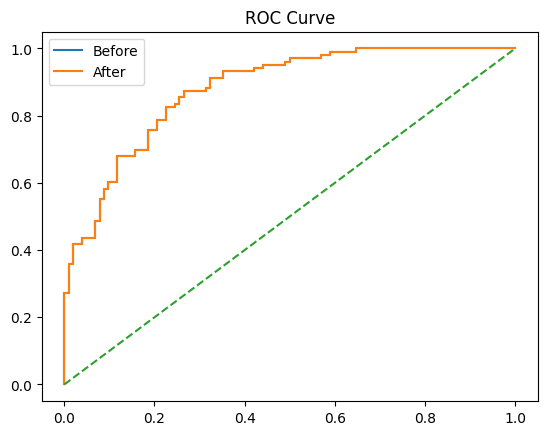

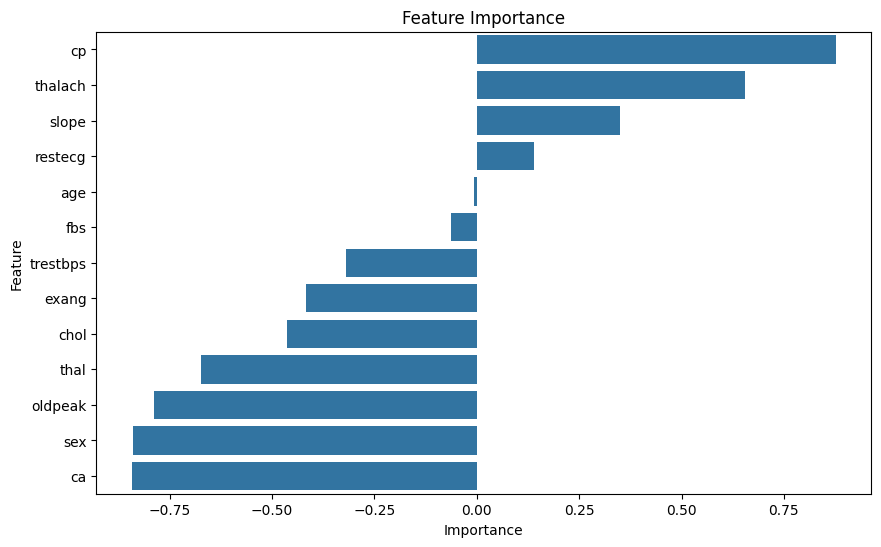

In [6]:
# ==========================================
# STEP 1: Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# ==========================================
# STEP 2: Load Dataset
# ==========================================
df = pd.read_csv('/content/heart.csv')

X = df.drop("target", axis=1)
y = df["target"]

feature_names = X.columns

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# ==========================================
# STEP 3: LINEAR REGRESSION
# ==========================================
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

print("\n===== LINEAR REGRESSION =====")
print("R2 Score:", r2_score(y_test, y_pred_lin))
print("MSE:", mean_squared_error(y_test, y_pred_lin))

# 🔹 GRAPH: Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred_lin)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# ==========================================
# STEP 4: LOGISTIC (BEFORE TUNING)
# ==========================================
model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
y_prob_before = model_before.predict_proba(X_test)[:, 1]

acc_before = accuracy_score(y_test, y_pred_before)

print("\n===== LOGISTIC BEFORE =====")
print("Accuracy:", acc_before)
print(classification_report(y_test, y_pred_before))

# ==========================================
# STEP 5: HYPERPARAMETER TUNING
# ==========================================
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

model_after = grid.best_estimator_

# ==========================================
# STEP 6: LOGISTIC (AFTER TUNING)
# ==========================================
y_pred_after = model_after.predict(X_test)
y_prob_after = model_after.predict_proba(X_test)[:, 1]

acc_after = accuracy_score(y_test, y_pred_after)

print("\n===== LOGISTIC AFTER =====")
print("Accuracy:", acc_after)
print(classification_report(y_test, y_pred_after))

# ==========================================
# STEP 7: ACCURACY COMPARISON
# ==========================================
plt.figure()
plt.bar(['Before', 'After'], [acc_before, acc_after])
plt.title("Accuracy Comparison")
plt.show()

# ==========================================
# STEP 8: CONFUSION MATRIX
# ==========================================
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred_before), annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Before")

sns.heatmap(confusion_matrix(y_test, y_pred_after), annot=True, fmt='d', ax=axes[1])
axes[1].set_title("After")

plt.show()

# ==========================================
# STEP 9: ROC (SINGLE COMBINED)
# ==========================================
fpr1, tpr1, _ = roc_curve(y_test, y_prob_before)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_after)

plt.figure()
plt.plot(fpr1, tpr1, label="Before")
plt.plot(fpr2, tpr2, label="After")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

# ==========================================
# STEP 10: FEATURE IMPORTANCE
# ==========================================
coefficients = model_after.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance")
plt.show()